In [ ]:
#importing libraries 
from dolfinx.io import XDMFFile
from dolfinx.mesh import meshtags_from_entities
from dolfinx.cpp.mesh import cell_entity_type
from dolfinx.io import distribute_entity_data
from dolfinx.graph import adjacencylist
from dolfinx.mesh import create_mesh
from dolfinx.cpp.mesh import to_type
from dolfinx.cpp.io import perm_gmsh
import numpy
from mpi4py import MPI
import dolfinx.io 
import numpy as np
import gmsh
import warnings
from dolfinx.io import VTXWriter, gmshio as gmshio
from basix.ufl import element
from dolfinx.fem import (
    Constant,
    Function,
    functionspace,
    assemble_scalar,
    dirichletbc,
    extract_function_spaces,
    form,
    locate_dofs_topological,
    set_bc,
)
from petsc4py import PETSc
import ufl
from dolfinx.fem.petsc import (
    apply_lifting,
    assemble_matrix,
    assemble_vector,
    create_vector,
    create_matrix,
    set_bc,
)
from ufl import (
    FacetNormal,
    Measure,
    TestFunction,
    TrialFunction,
    as_vector,
    div,
    dot,
    dx,
    inner,
    lhs,
    grad,
    nabla_grad,
    rhs,
)
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
import tqdm.autonotebook

: 

In [ ]:
#creating the geomtery and then mesh
import gmsh
gmsh.initialize()
gmsh.model.add("box_with_positioned_object")

# Create box with padding
box_padding = 1.0  # Space between object and box walls
box_width = 10.0
box_height = 5.0
box_depth = 3.0
box = gmsh.model.occ.addBox(0, 0, 0, box_width, box_height, box_depth)
#box = gmsh.model.occ.addCylinder(0,0,0,box_width,box_height,box_depth,1.5)
# Import STEP file
imported = gmsh.model.occ.importShapes("Gmsh_foil2.step")

# Recalculate dimensions after scaling
xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.occ.getBoundingBox(
    imported[0][0], imported[0][1]
)
print(xmin, ymin, zmin, xmax, ymax, zmax)
obj_width = xmax - xmin
obj_height = ymax - ymin
obj_depth = zmax - zmin

# Position at center of box
center_x = (box_width - obj_width) / 2
center_y = (box_height - obj_height) / 2
center_z = (box_depth - obj_depth) / 2

# Translate to desired position
gmsh.model.occ.translate(imported, center_x, center_y, center_z)

# Create assembly (group objects together)
fluid_domain = gmsh.model.occ.cut([(3, box)], imported)
gmsh.model.occ.synchronize()

# Get all volumes (should be just fluid domain after cut)
all_volumes = gmsh.model.getEntities(3)
fluid_volume_tag = all_volumes[0][1]

# Create physical group for FLUID DOMAIN
gmsh.model.addPhysicalGroup(3, [fluid_volume_tag], 100)
gmsh.model.setPhysicalName(3, 100, "FluidDomain")


all_surfaces = gmsh.model.getEntities(2)
print(all_surfaces)

# Identify boundaries by position for CFD
inlet_surfaces = []
outlet_surfaces = []
walls_surfaces = []
object_surfaces = []

for dim, tag in all_surfaces:
    # Get surface center
    com = gmsh.model.occ.getCenterOfMass(dim, tag)
    x, y, z = com
    # Classify boundaries
    if abs(x - 0) < 0.1:  # x=0 face
        inlet_surfaces.append(tag)
    elif abs(x - 10) < 0.1:  # x=20 face
        outlet_surfaces.append(tag)
    elif abs(y - 0) < 0.1 or abs(y - 5) < 0.1 or abs(z - 0) < 0.1 or abs(z - 3) < 0.1:
        walls_surfaces.append(tag)  # box walls
    else:
        object_surfaces.append(tag)  # object surface
# Create physical groups for boundaries
if inlet_surfaces:
    gmsh.model.addPhysicalGroup(2, inlet_surfaces, 200)
    gmsh.model.setPhysicalName(2, 200, "Inlet")

if outlet_surfaces:
    gmsh.model.addPhysicalGroup(2, outlet_surfaces, 201)
    gmsh.model.setPhysicalName(2, 201, "Outlet")

if walls_surfaces:
    gmsh.model.addPhysicalGroup(2, walls_surfaces, 202)
    gmsh.model.setPhysicalName(2, 202, "Walls")

if object_surfaces:
    gmsh.model.addPhysicalGroup(2, object_surfaces, 203)
    gmsh.model.setPhysicalName(2, 203, "Obstacle")
print("="*50)
print("Boundary conditions defined:")
print(f"  Inlet:    {len(inlet_surfaces)} surfaces")
print(f"  Outlet:   {len(outlet_surfaces)} surfaces")
print(f"  Walls:    {len(walls_surfaces)} surfaces")
print(f"  Obstacle: {len(object_surfaces)} surfaces")
print("="*50)
r=1
distance = gmsh.model.mesh.field.add("Distance")
gmsh.model.mesh.field.setNumbers(distance, "FacesList", object_surfaces)
resolution = r / 10
threshold = gmsh.model.mesh.field.add("Threshold")
gmsh.model.mesh.field.setNumber(threshold, "IField", distance)
gmsh.model.mesh.field.setNumber(threshold, "LcMin", resolution)
gmsh.model.mesh.field.setNumber(threshold, "LcMax", 1.0)
gmsh.model.mesh.field.setNumber(threshold, "DistMin", 0.1)
gmsh.model.mesh.field.setNumber(threshold, "DistMax", 0.5)
inlet_dist = gmsh.model.mesh.field.add("Distance")
gmsh.model.mesh.field.setNumbers(inlet_dist, "FacesList", [inlet_surfaces[0]])
inlet_thre = gmsh.model.mesh.field.add("Threshold")
gmsh.model.mesh.field.setNumber(inlet_thre, "IField", inlet_dist)
gmsh.model.mesh.field.setNumber(inlet_thre, "LcMin", 5 * resolution)
gmsh.model.mesh.field.setNumber(inlet_thre, "LcMax", 10 * resolution)
gmsh.model.mesh.field.setNumber(inlet_thre, "DistMin", 0.1)
gmsh.model.mesh.field.setNumber(inlet_thre, "DistMax", 0.5)
minimum = gmsh.model.mesh.field.add("Min")
gmsh.model.mesh.field.setNumbers(minimum, "FieldsList", [threshold, inlet_thre])
gmsh.model.mesh.field.setAsBackgroundMesh(minimum)
gmsh.model.occ.synchronize()
gmsh.model.mesh.generate(3)
# Optional: Refine mesh (improve quality)
gmsh.model.mesh.refine()
print("Mesh refined")
# Optional: Smooth the mesh
gmsh.model.mesh.optimize("Laplace2D", niter=10)
gmsh.model.mesh.optimize("Netgen", niter=10)
print("Mesh smoothed and optimized")

#gmsh.fltk.run()


Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 2/3/Open CASCADE STEP translator 7.8 2.1' (3D)
Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 2/4/Open CASCADE STEP translator 7.8 2.2' (3D)
-1e-07 -0.06001895423294 -1e-07 1.0000001 0.06001895423294 0.3000001
[(2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16)]                                                        
Boundary conditions defined:
  Inlet:    1 surfaces
  Outlet:   1 surfaces
  Walls:    4 surfaces
  Obstacle: 4 surfaces
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 13 (Line)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 20%] Meshing curve 16 (BSpline)
Info    : [ 30%] Meshing curve 17 (BSpline)
Info    : [ 30%] Meshing curve 18 (BSpline)
Info    : [ 40%] Meshing curve 19 (Line)
Info    : [ 40%] Meshing curve 20 (Line)
Info    : [ 50%] Meshing curve 21 (Line)
Info    : [ 60%] Meshing curve 22 (Line)
Info  

In [ ]:
#importing the geometry into dolfinx
model_rank = 0
mesh, cell_tags, facet_tags = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, model_rank)

In [ ]:
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

print(f"Hello from process {rank} of {size}")

Hello from process 0 of 1


In [ ]:
#parameters
t = 0.0
T = 50.0  # Final time
dt = 1 / 5  # Time step size
num_steps = int(T / dt)
k = Constant(mesh, PETSc.ScalarType(dt))
mu = Constant(mesh, PETSc.ScalarType(0.001))  # Dynamic viscosity
rho = Constant(mesh, PETSc.ScalarType(1))  # Density

u_inlet = Function(V)
Creates a finite element function in the velocity space V. Allocates memory for velocity values at all degrees of freedom. Initially contains zeros. Can store both 2D (u_x, u_y) or 3D (u_x, u_y, u_z) velocity fields

u_inlet.interpolate(inlet_velocity)
Evaluates inlet_velocity(x) at all nodal points of the mesh. Assigns these values to the degrees of freedom of u_inlet. Makes the analytical function usable in the FEM discretization

In [ ]:
#Defining the boundary conditions
v_cg2 = element("Lagrange", mesh.basix_cell(), 2, shape=(mesh.geometry.dim,))    #used to define the velocity as vector field so that it can have x,y,z compenent
s_cg1 = element("Lagrange", mesh.basix_cell(), 1)   #same goes for pressure because we need velocity and pressure for all points in the mesh
V = functionspace(mesh, v_cg2)      #Creates the global numbering of degrees of freedom for velocity
Q = functionspace(mesh, s_cg1)      #Creates the global numbering for pressure degrees of freedom
    
    
fdim = mesh.topology.dim - 1        #facet dimention
# Inlet
class InletVelocity:
    def __init__(self, t, Umax):
        self.t = t
        self.Umax = Umax

        # from addBox(0,0,0, 10,5,3)
        self.y_min, self.y_max = 0.0, 5.0
        self.z_min, self.z_max = 0.0, 3.0

    def __call__(self, x):
        values = np.zeros((3, x.shape[1]), dtype=PETSc.ScalarType)

        y = x[1]
        z = x[2]

        H = self.y_max - self.y_min  # 5
        W = self.z_max - self.z_min  # 3

        eta = (y - self.y_min) / H
        xi  = (z - self.z_min) / W

        # clamp (helps if mesh coords are like 5.0000000002 etc.)
        eta = np.clip(eta, 0.0, 1.0)
        xi  = np.clip(xi,  0.0, 1.0)

        # 3D parabolic profile: zero on all inlet edges, max at center
        values[0] = self.Umax * 16.0 * eta * (1.0 - eta) * xi * (1.0 - xi)
        
        return values
# Inlet
u_inlet = Function(V)
inlet_velocity = InletVelocity(t,0.5)                         #i can define the velocity wtr to time if i want just use the code in ns2
u_inlet.interpolate(inlet_velocity)
bcu_inflow = dirichletbc(
    u_inlet, locate_dofs_topological(V, fdim, facet_tags.find(200))             #we are finding the inlet facet tags to know which part is the inlet using facet_tags.find, then finding the inlet degree of freedom
)
# Walls
u_nonslip = np.array((0,) * mesh.geometry.dim, dtype=PETSc.ScalarType)                   #creating a vector of zeros whose lengtj-h is equal to the spatial dimentions 3D that is obtained by the  mesh.geometry.dim since we are using non slip condition
bcu_walls = dirichletbc(
    u_nonslip, locate_dofs_topological(V, fdim, facet_tags.find(202)), V         # V here specifes the function spave to which the boundary condtion applies
)
# Obstacle
bcu_obstacle = dirichletbc(
    u_nonslip, locate_dofs_topological(V, fdim, facet_tags.find(203)), V     #same no slip condition applied to obstacle
)
bcu = [bcu_inflow, bcu_obstacle, bcu_walls]
# Outlet
bcp_outlet = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(Q, fdim, facet_tags.find(201)), Q
)
bcp = [bcp_outlet]

writing the weak formulation / variational form of the naovier stokes equations

considering u as velocity, v as test function, p as pressure, mu as viscosity and rou=1 as density. we have the following formulation



test function of momentum equation is defines by a velocity test function v and the conitnuity equation is multiplied by the pressure test function q, that integrates over the domain.




In [ ]:
#defining the functions 
u = ufl.TrialFunction(V)                    #trial function for velocity
v = ufl.TestFunction(V)                      #test function for velocity
u_ = Function(V, name="u")
u_s = Function(V, name="u_tentative")
u_n = Function(V)
u_n1 = Function(V)
p = ufl.TrialFunction(Q)                 #trial function for presssure
q = ufl.TestFunction(Q)                  #test function for presssure
p_ = Function(Q, name="p")
phi = Function(Q, name="phi")



In [ ]:
#writing the variational form first step
f = Constant(mesh, PETSc.ScalarType((0, 0,0)))
F1 = rho / k * dot(u - u_n, v) * dx
F1 += inner(dot(1.5 * u_n - 0.5 * u_n1, 0.5 * nabla_grad(u + u_n)), v) * dx
F1 += 0.5 * mu * inner(grad(u + u_n), grad(v)) * dx - dot(p_, div(v)) * dx
F1 += dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))
A1 = create_matrix(a1)
# b1 = create_vector(extract_function_spaces(L1))
b1 = create_vector((L1))
print("Topological dimension:", mesh.topology.dim)
print("Number of vertices:", mesh.geometry.x.shape[0])
print("Number of cells:", mesh.topology.index_map(mesh.topology.dim).size_local)

Topological dimension: 3
Number of vertices: 4476
Number of cells: 20435


In [ ]:
#2nd step
a2 = form(dot(grad(p), grad(q)) * dx)
L2 = form(-rho / k * dot(div(u_s), q) * dx)
A2 = assemble_matrix(a2, bcs=bcp)
A2.assemble()
# b2 = create_vector(extract_function_spaces(L2))
b2 = create_vector((L2))

In [ ]:
#3rd step
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_s, v) * dx - k * dot(nabla_grad(phi), v) * dx)
A3 = assemble_matrix(a3)
A3.assemble()
# b3 = create_vector(extract_function_spaces(L3))
b3 = create_vector((L3))

In [ ]:
# Solver for step 1
solver1 = PETSc.KSP().create(mesh.comm)
solver1.setOperators(A1)
solver1.setType(PETSc.KSP.Type.BCGS)
pc1 = solver1.getPC()
pc1.setType(PETSc.PC.Type.JACOBI)

# Solver for step 2
solver2 = PETSc.KSP().create(mesh.comm)
solver2.setOperators(A2)
solver2.setType(PETSc.KSP.Type.GMRES)
pc2 = solver2.getPC()
pc2.setType(PETSc.PC.Type.HYPRE)
pc2.setHYPREType("boomeramg")

# Solver for step 3
solver3 = PETSc.KSP().create(mesh.comm)
solver3.setOperators(A3)
solver3.setType(PETSc.KSP.Type.CG)
pc3 = solver3.getPC()
pc3.setType(PETSc.PC.Type.SOR)

In [ ]:
# In 3D, ensure n points OUT of the fluid and INTO the obstacle for standard sign convention
n = -FacetNormal(mesh) 
dObs = Measure("ds", domain=mesh, subdomain_data=facet_tags, subdomain_id=203)

# --- 2. Fluid Stress Tensor (Turbulent) ---
# sigma = -p*I + (mu + mu_t)*(grad(u) + grad(u).T)
# This accounts for both pressure and skin friction in 3D
epsilon = lambda u: 0.5 * (ufl.grad(u) + ufl.grad(u).T)
sigma = -p_ * ufl.Identity(len(u_)) + 2.0 * (mu) * epsilon(u_)

# --- 3. Directional Vectors ---
# Drag is usually along the X-axis, Lift along the Z-axis (3D height)
# Adjust these based on your specific flow orientation
drag_direction = Constant(mesh, np.array([1.0, 0.0, 0.0], dtype=np.float64))
lift_direction = Constant(mesh, np.array([0.0, 0.0, 1.0], dtype=np.float64))

# --- 4. Projected Reference Area (A_ref) ---
# Automatically calculate planform area (shadow on XY plane)
# This replaces the static '0.1' divisor from your 2D code
A_ref = mesh.comm.allreduce(
assemble_scalar(form(1.0 * dObs)),
op=MPI.SUM
)
if mesh.comm.rank == 0:
    print("Wing surface area =", A_ref)

# --- 5. Force Forms ---
# We integrate the traction vector (sigma * n) dotted with the direction
drag_force_form = form(ufl.dot(ufl.dot(sigma, n), drag_direction) * dObs)
lift_force_form = form(ufl.dot(ufl.dot(sigma, n), lift_direction) * dObs)

# --- 6. Initialization (Rank 0) ---
if mesh.comm.rank == 0:
    print(f"Calculated 3D Reference Area: {A_ref:.6f}")
    C_D = np.zeros(num_steps, dtype=PETSc.ScalarType)
    C_L = np.zeros(num_steps, dtype=PETSc.ScalarType)
    t_u = np.zeros(num_steps, dtype=np.float64)
    t_p = np.zeros(num_steps, dtype=np.float64)

#Below we did something to find the pressure difference
tree = bb_tree(mesh, mesh.geometry.dim)
# points = np.array([[0.5, 0, 0.2], [0, 0.41, 0]])
points = np.array([[0 ,-0.06001895423294, 0], [1.0000001, 0.06001895423294, 0.3000001]])
cell_candidates = compute_collisions_points(tree, points)
colliding_cells = compute_colliding_cells(mesh, cell_candidates, points)
front_cells = colliding_cells.links(0)
back_cells = colliding_cells.links(1)
if mesh.comm.rank == 0:
    p_diff = np.zeros(num_steps, dtype=PETSc.ScalarType)

Wing surface area = 0.7731018257953823
Calculated 3D Reference Area: 0.773102


In [ ]:
from dolfinx.io import VTKFile
from pathlib import Path
folder = Path("results")
folder.mkdir(exist_ok=True, parents=True)
vtk_u = VTKFile(mesh.comm, str(folder / "velocity.pvd"), "w")  # open once
vtk_p = VTKFile(mesh.comm, str(folder / "pressure.pvd"), "w")  # open once
progress = tqdm.autonotebook.tqdm(desc="Solving PDE", total=num_steps)
for i in range(num_steps):
    progress.update(1)
    # Update current time step
    t += dt
    # Update inlet velocity
    inlet_velocity.t = t
    u_inlet.interpolate(inlet_velocity)

    # Step 1: Tentative velocity step
    A1.zeroEntries()
    assemble_matrix(A1, a1, bcs=bcu)
    A1.assemble()
    with b1.localForm() as loc:
        loc.set(0)
    assemble_vector(b1, L1)
    apply_lifting(b1, [a1], [bcu])
    b1.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b1, bcu)
    solver1.solve(b1, u_s.x.petsc_vec)
    u_s.x.scatter_forward()
    print("step 1 done")
    # Step 2: Pressure corrrection step
    with b2.localForm() as loc:
        loc.set(0)
    assemble_vector(b2, L2)
    apply_lifting(b2, [a2], [bcp])
    b2.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b2, bcp)
    solver2.solve(b2, phi.x.petsc_vec)
    phi.x.scatter_forward()

    p_.x.petsc_vec.axpy(1, phi.x.petsc_vec)
    p_.x.scatter_forward()
    print("step 2 done")
    # Step 3: Velocity correction step
    with b3.localForm() as loc:
        loc.set(0)
    assemble_vector(b3, L3)
    b3.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    solver3.solve(b3, u_.x.petsc_vec)
    u_.x.scatter_forward()

    # Write solutions to file
    vtk_u.write_function(u_, t)   # writes vector velocity at time t
    vtk_p.write_function(p_, t)

    # Update variable with solution form this time step
    with (
        u_.x.petsc_vec.localForm() as loc_,
        u_n.x.petsc_vec.localForm() as loc_n,
        u_n1.x.petsc_vec.localForm() as loc_n1,
    ):
        loc_n.copy(loc_n1)
        loc_.copy(loc_n)
    print("step 3 done")
    # Compute physical quantities
    # For this to work in paralell, we gather contributions from all processors
    # to processor zero and sum the contributions.
    force_d = mesh.comm.allreduce(assemble_scalar(drag_force_form), op=MPI.SUM)
    print("1")
    force_l = mesh.comm.allreduce(assemble_scalar(lift_force_form), op=MPI.SUM)
    print("2")
    # 2. Normalize by dynamic pressure: 0.5 * rho * U^2 * A_ref
    # Assuming rho=1.0 and U_inlet=0.1 from your code
    dynamic_pressure = 0.5 * rho * (0.5)**2 * A_ref
    p_front = None
    if len(front_cells) > 0:
        p_front = p_.eval(points[0], front_cells[:1])
    p_front = mesh.comm.gather(p_front, root=0)
    print("3")
    p_back = None
    if len(back_cells) > 0:
        p_back = p_.eval(points[1], back_cells[:1])
    p_back = mesh.comm.gather(p_back, root=0)
    print("4")
    if mesh.comm.rank == 0:
        t_u[i] = t
        t_p[i] = t - dt / 2
        C_D[i] = (force_d)
        C_L[i] = (force_l)
        # Choose first pressure that is found from the different processors
        for pressure in p_front:
            if pressure is not None:
                p_diff[i] = pressure[0]
                break
        for pressure in p_back:
            if pressure is not None:
                p_diff[i] -= pressure[0]
                break
    print("5")
progress.close()
vtk_u.close()
vtk_p.close()

Solving PDE:   0%|          | 0/500 [00:00<?, ?it/s]

step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 done
1
2
3
4
5
step 1 done
step 2 done
step 3 don

In [ ]:
print(C_D)

[0.59392346 0.34340919 0.05002356 0.05272692 0.05821454 0.05700185
 0.05342534 0.05098177 0.04878406 0.0470006  0.04541845 0.04408157
 0.04290807 0.04189033 0.04098853 0.04019063 0.03947388 0.03883268
 0.0382538  0.03772896 0.03725167 0.03681656 0.03641858 0.0360537
 0.03571837 0.03540965 0.03512498 0.03486221 0.03461945 0.03439504
 0.03418754 0.03399562 0.0338181  0.03365387 0.03350193 0.03336136
 0.0332313  0.033111   0.03299974 0.03289689 0.03280189 0.03271425
 0.03263351 0.03255926 0.03249114 0.03242879 0.03237188 0.03232012
 0.0322732  0.03223087 0.03219291 0.03215913 0.03212939 0.03210355
 0.03208154 0.03206327 0.03204868 0.03203773 0.03203037 0.03202654
 0.03202621 0.03202654 0.03203142 0.0320411  0.03205412 0.03207034
 0.03208974 0.03211225 0.03213783 0.03216643 0.03219801 0.03223257
 0.0322701  0.0323106  0.03235409 0.03240059 0.03245015 0.03250277
 0.03255852 0.03261742 0.03267955 0.03274501 0.03281394 0.03288654
 0.03296309 0.03304391 0.03312943 0.0332201  0.03331646 0.03341

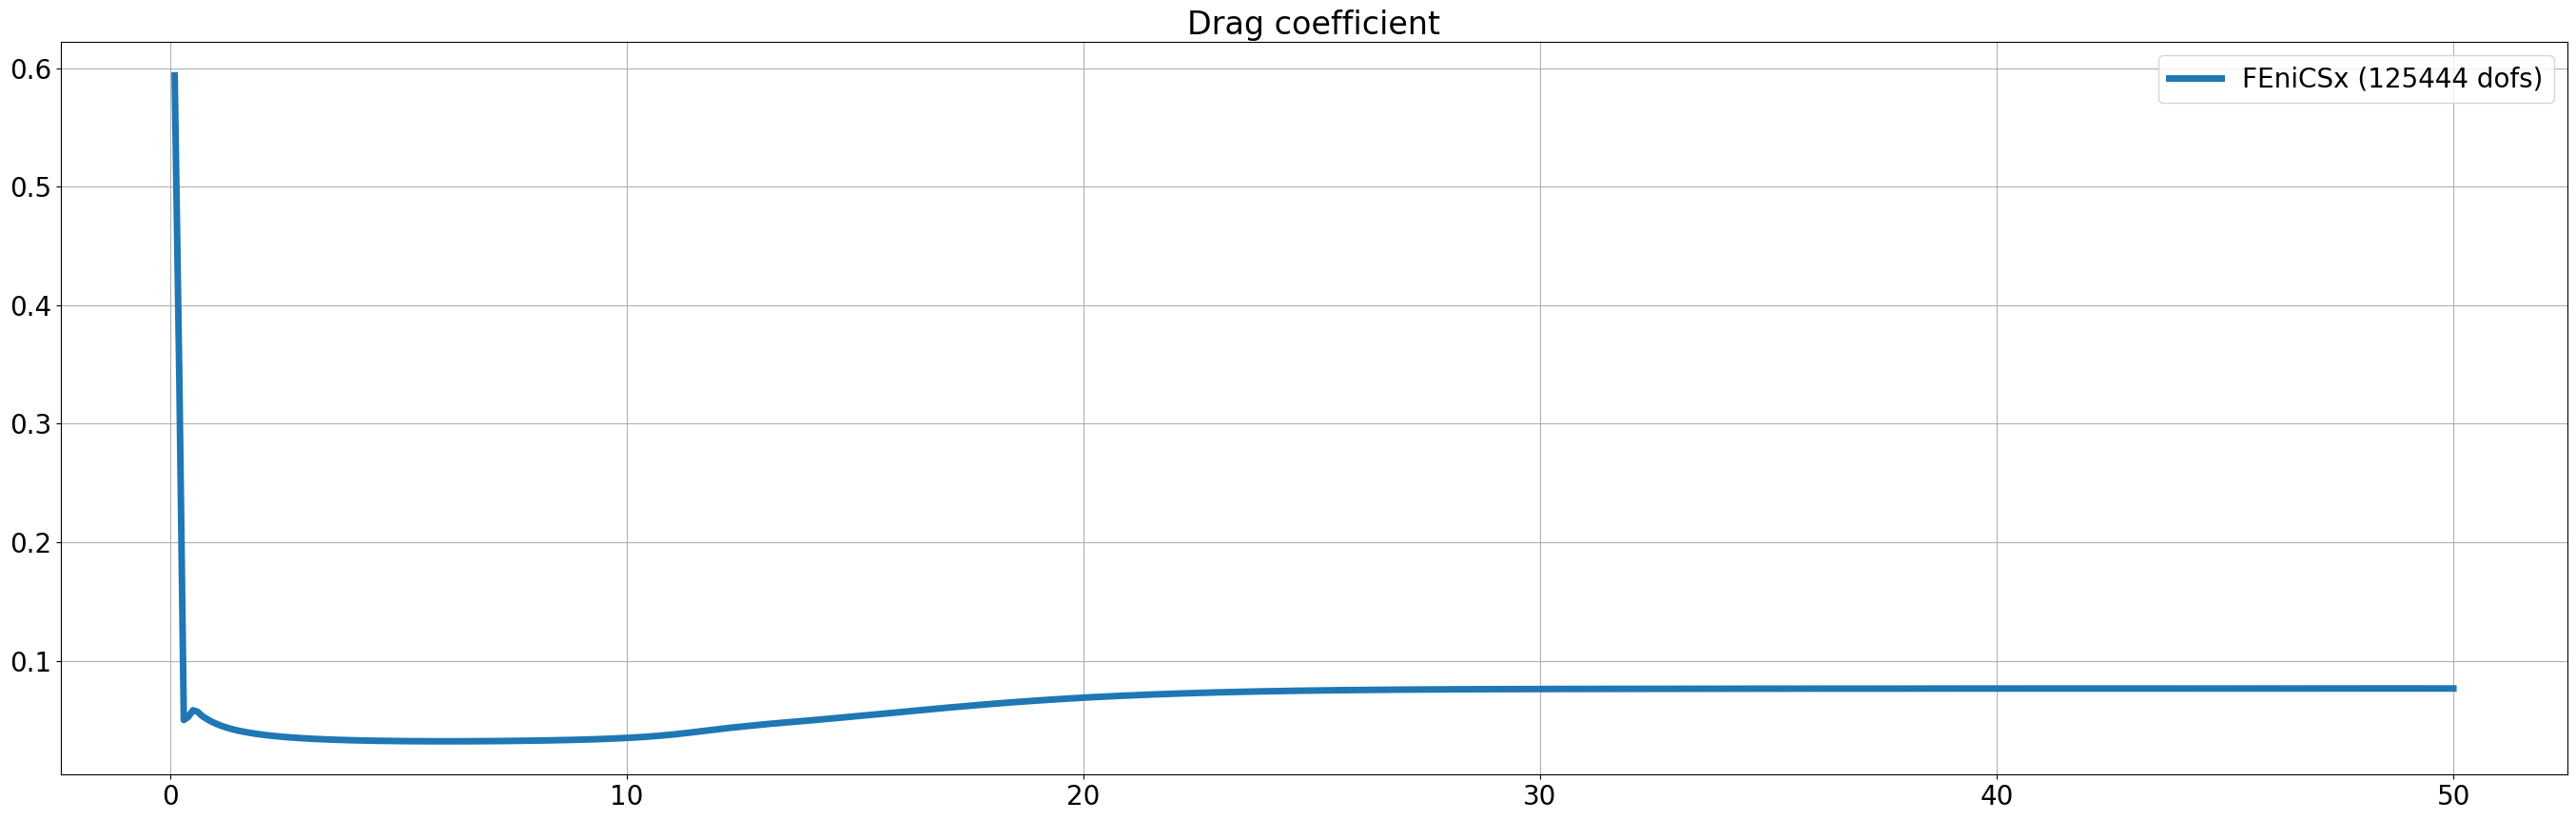

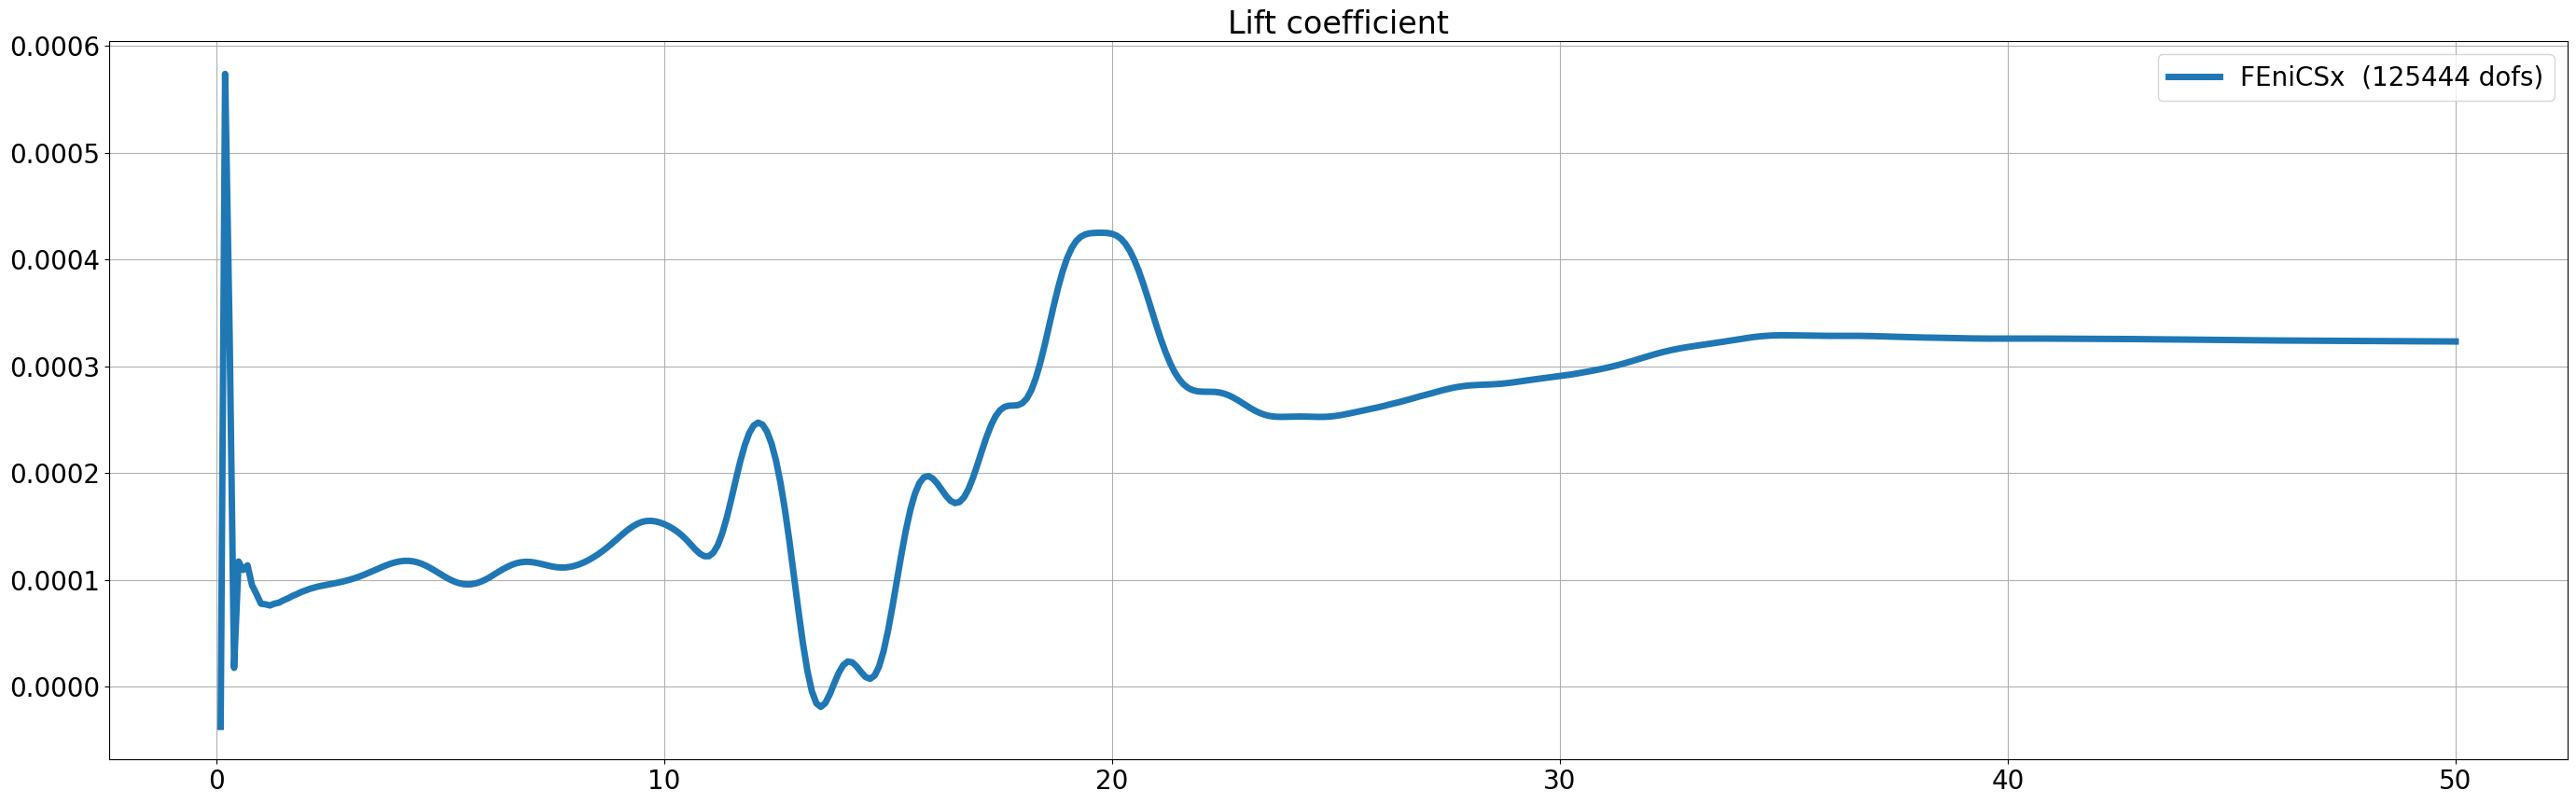

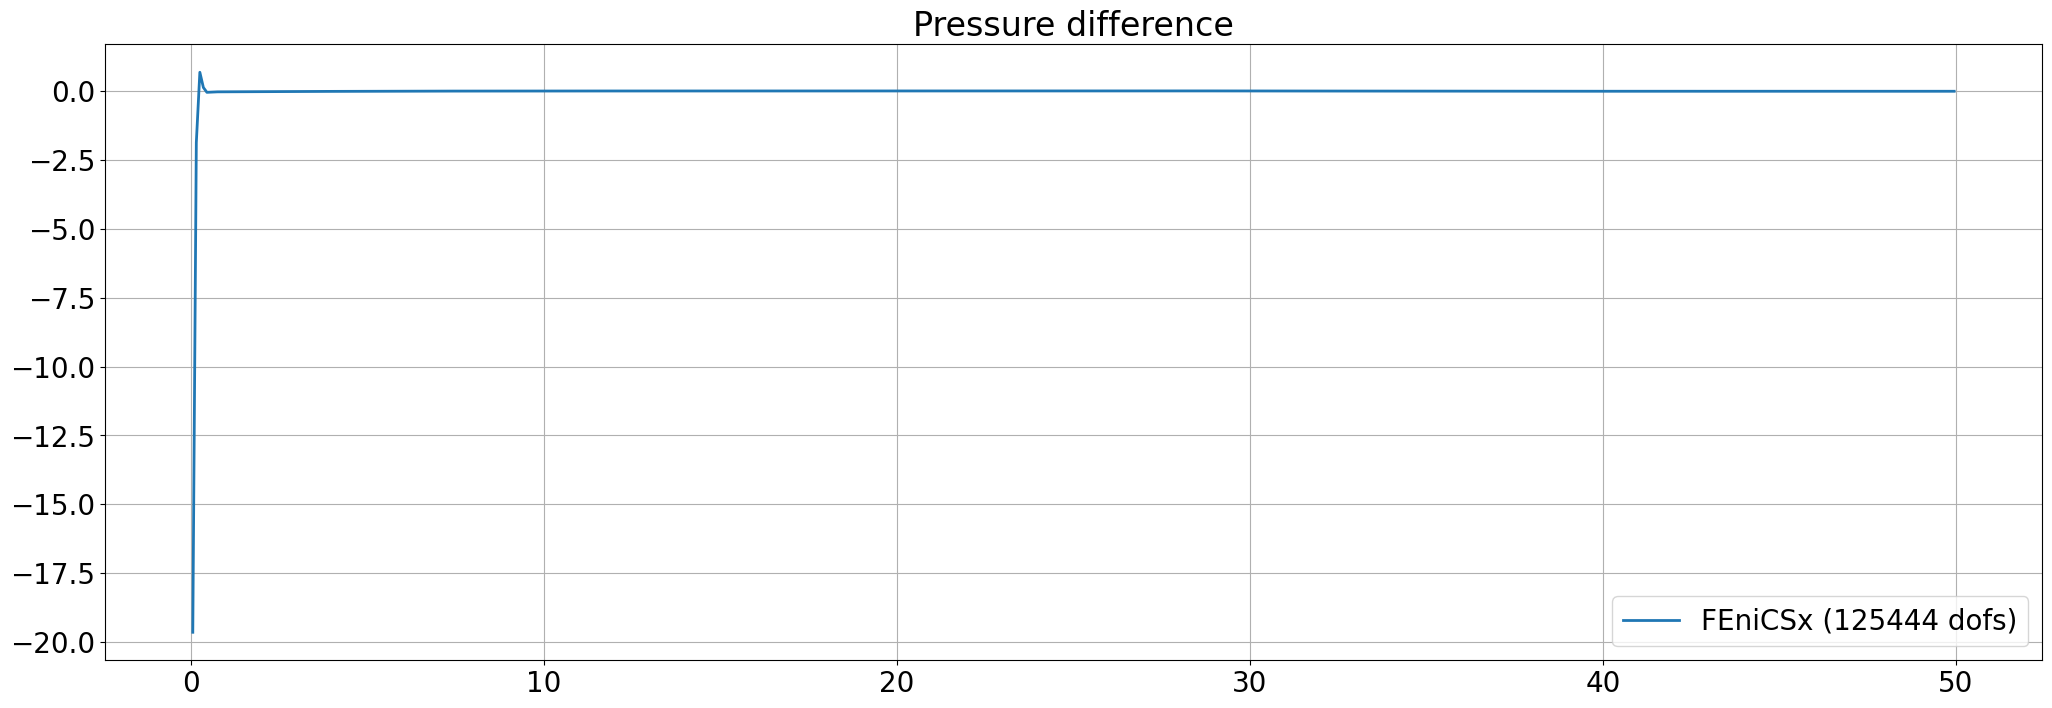

In [ ]:
import os
import matplotlib.pyplot as plt
if mesh.comm.rank == 0:
    if not os.path.exists("figures"):
        os.mkdir("figures")
    num_velocity_dofs = V.dofmap.index_map_bs * V.dofmap.index_map.size_global
    num_pressure_dofs = Q.dofmap.index_map_bs * V.dofmap.index_map.size_global


    # fig = plt.figure(figsize=(20, 8))
    # l1 = plt.plot(
    #     t_u,
    #     C_D,
    #     label=r"FEniCSx  ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
    #     linewidth=2,
    # )

    plt.rcParams.update({'font.size': 20}) # Increased from default (e.g., to 20)

    
    fig = plt.figure(figsize=(34, 10))
    l1 = plt.plot(
        t_u,
        C_D,
        label=r"FEniCSx ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
        linewidth=5, # Increased from 2 to 5 for a thicker line
    )


    plt.title("Drag coefficient")
    plt.grid()
    plt.legend()
    plt.savefig("figures/drag_comparison_3D_wing.png")
    plt.rcParams.update({'font.size': 20})
    fig = plt.figure(figsize=(34, 10))
    l1 = plt.plot(
        t_u,
        C_L,
        label=r"FEniCSx  ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
        linewidth=5,
    )

    plt.title("Lift coefficient")
    plt.grid()
    plt.legend()
    plt.savefig("figures/lift_comparison_3D_wing.png")

    fig = plt.figure(figsize=(25, 8))
    l1 = plt.plot(
        t_p,
        p_diff,
        label=r"FEniCSx ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
        linewidth=2,
    )

    plt.title("Pressure difference")
    plt.grid()
    plt.legend()
    plt.savefig("figures/pressure_comparison_3D_wing.png")

In [ ]:
import numpy as np
import pyvista as pv

# ----------------------------
# User controls
# ----------------------------
PVD_FILE = "results/velocity.pvd"
TIME_INDEX = 10           # <-- choose time step index here
SLICE_NORMAL = (0, 0, 1)   # (0,0,1)=XY, (0,1,0)=XZ, (1,0,0)=YZ
COLORMAP = "viridis"

# ----------------------------
# Load time-series
# ----------------------------
reader = pv.get_reader(PVD_FILE)
time_values = reader.time_values

if len(time_values) == 0:
    raise RuntimeError("No time steps found in the PVD file.")

if TIME_INDEX >= len(time_values):
    raise ValueError(f"TIME_INDEX must be < {len(time_values)}")

# Activate selected time step
reader.set_active_time_value(time_values[TIME_INDEX])
data = reader.read()

# Handle MultiBlock output (common with DOLFINx)
if isinstance(data, pv.MultiBlock):
    grid = data[0]
else:
    grid = data

# ----------------------------
# Compute velocity magnitude |u|
# ----------------------------
velocity = grid.point_data["u"]
speed = np.linalg.norm(velocity, axis=1)
grid.point_data["|u|"] = speed

# ----------------------------
# Slice domain
# ----------------------------
slice_xy = grid.slice(normal=SLICE_NORMAL)

# ----------------------------
# Plot
# ----------------------------
p = pv.Plotter()
p.add_mesh(slice_xy, scalars="|u|", cmap=COLORMAP)
p.add_scalar_bar("|u|")
p.add_text(f"Time index: {TIME_INDEX}\nTime value: {time_values[TIME_INDEX]:.4f}")
p.show()


Widget(value='<iframe src="http://localhost:36133/index.html?ui=P_0x72cad789d0c0_0&reconnect=auto" class="pyvi…

In [ ]:
import numpy as np
import pyvista as pv

# ----------------------------
# User controls
# ----------------------------
PVD_FILE = "results/pressure.pvd"
TIME_INDEX = 10            # <-- choose time step index here
SLICE_NORMAL = (0, 0, 1)   # (0,0,1)=XY, (0,1,0)=XZ, (1,0,0)=YZ
COLORMAP = "viridis"

# ----------------------------
# Load time-series
# ----------------------------
reader = pv.get_reader(PVD_FILE)
time_values = reader.time_values

if len(time_values) == 0:
    raise RuntimeError("No time steps found in the PVD file.")

if TIME_INDEX >= len(time_values):
    raise ValueError(f"TIME_INDEX must be < {len(time_values)}")

# Activate selected time step
reader.set_active_time_value(time_values[TIME_INDEX])
data = reader.read()

# Handle MultiBlock output (common with DOLFINx)
if isinstance(data, pv.MultiBlock):
    grid = data[0]
else:
    grid = data

# ----------------------------
# Compute velocity magnitude |u|
# ----------------------------
velocity = grid.point_data["p"]
speed = np.linalg.norm(velocity)
grid.point_data["|p|"] = speed

# ----------------------------
# Slice domain
# ----------------------------
slice_xy = grid.slice(normal=SLICE_NORMAL)

# ----------------------------
# Plot
# ----------------------------
p = pv.Plotter()
p.add_mesh(slice_xy, scalars="|p|", cmap=COLORMAP)
p.add_scalar_bar("|p|")
p.add_text(f"Time index: {TIME_INDEX}\nTime value: {time_values[TIME_INDEX]:.4f}")
p.show()


Widget(value='<iframe src="http://localhost:36133/index.html?ui=P_0x72cad7926d70_1&reconnect=auto" class="pyvi…